<a href="https://colab.research.google.com/github/vieronicka/2020csc065/blob/main/Part1_NIDS_Baseline_Split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Baseline NIDS Data Preparation and Model Training

**Research Project**: Adaptive Adversarial Defense for Network Intrusion Detection Systems using Dynamic GAN Ensembles

**Part 1 Contents**:
- Data loading and preprocessing
- Feature engineering and selection
- Baseline model training (Random Forest)
- Vulnerability analysis
- Save processed data for subsequent parts

**Note**: This is the first part of the split notebook. Run this completely before proceeding to Part 2.

In [4]:
# import required libraries
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
import time
import random
from numpy import array
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import mutual_info_classif
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import completeness_score, homogeneity_score, v_measure_score
from sklearn.model_selection import train_test_split

# Additional imports for adversarial attacks
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# path to where ML files are stored
path = '/content/drive/MyDrive/Colab Notebooks/Research/Dataset_NIDS/MachineLearningCVE'
all_files = glob.glob(path + "/*.csv")

# concatenate the 8 files into 1
dataset = pd.concat((pd.read_csv(f) for f in all_files))
dataset.to_csv('combined_dataset.csv', index=False)

In [5]:
#duplicatedd the cell to save in correct path
# path to where ML files are stored
path = '/content/drive/MyDrive/Colab Notebooks/Research/Dataset_NIDS/MachineLearningCVE'
all_files = glob.glob(path + "/*.csv")

# concatenate the 8 files into 1
dataset = pd.concat((pd.read_csv(f) for f in all_files))
dataset.to_csv('/content/drive/MyDrive/Colab Notebooks/Research/Dataset_NIDScombined_dataset.csv', index=False)

In [4]:
pd.set_option('display.max_rows', 80)

In [5]:
dataset.dtypes

,0
Destination Port,int64
Flow Duration,int64
Total Fwd Packets,int64
Total Backward Packets,int64
Total Length of Fwd Packets,int64
Total Length of Bwd Packets,int64
Fwd Packet Length Max,int64
Fwd Packet Length Min,int64
Fwd Packet Length Mean,float64
Fwd Packet Length Std,float64


In [6]:
col_names = ["Destination_Port",
            "Flow_Duration",
            "Total_Fwd_Packets",
            "Total_Backward_Packets",
            "Total_Length_of_Fwd_Packets",
            "Total_Length_of_Bwd_Packets",
            "Fwd_Packet_Length_Max",
            "Fwd_Packet_Length_Min",
            "Fwd_Packet_Length_Mean",
            "Fwd_Packet_Length_Std",
            "Bwd_Packet_Length_Max",
            "Bwd_Packet_Length_Min",
            "Bwd_Packet_Length_Mean",
            "Bwd_Packet_Length_Std",
            "Flow_Bytes_s",
            "Flow_Packets_s",
            "Flow_IAT_Mean",
            "Flow_IAT_Std",
            "Flow_IAT_Max",
            "Flow_IAT_Min",
            "Fwd_IAT_Total",
            "Fwd_IAT_Mean",
            "Fwd_IAT_Std",
            "Fwd_IAT_Max",
            "Fwd_IAT_Min",
            "Bwd_IAT_Total",
            "Bwd_IAT_Mean",
            "Bwd_IAT_Std",
            "Bwd_IAT_Max",
            "Bwd_IAT_Min",
            "Fwd_PSH_Flags",
            "Bwd_PSH_Flags",
            "Fwd_URG_Flags",
            "Bwd_URG_Flags",
            "Fwd_Header_Length",
            "Bwd_Header_Length",
            "Fwd_Packets_s",
            "Bwd_Packets_s",
            "Min_Packet_Length",
            "Max_Packet_Length",
            "Packet_Length_Mean",
            "Packet_Length_Std",
            "Packet_Length_Variance",
            "FIN_Flag_Count",
            "SYN_Flag_Count",
            "RST_Flag_Count",
            "PSH_Flag_Count",
            "ACK_Flag_Count",
            "URG_Flag_Count",
            "CWE_Flag_Count",
            "ECE_Flag_Count",
            "Down_Up_Ratio",
            "Average_Packet_Size",
            "Avg_Fwd_Segment_Size",
            "Avg_Bwd_Segment_Size",
            "Fwd_Header_Length",
            "Fwd_Avg_Bytes_Bulk",
            "Fwd_Avg_Packets_Bulk",
            "Fwd_Avg_Bulk_Rate",
            "Bwd_Avg_Bytes_Bulk",
            "Bwd_Avg_Packets_Bulk",
            "Bwd_Avg_Bulk_Rate",
            "Subflow_Fwd_Packets",
            "Subflow_Fwd_Bytes",
            "Subflow_Bwd_Packets",
            "Subflow_Bwd_Bytes",
            "Init_Win_bytes_forward",
            "Init_Win_bytes_backward",
            "act_data_pkt_fwd",
            "min_seg_size_forward",
            "Active_Mean",
            "Active_Std",
            "Active_Max",
            "Active_Min",
            "Idle_Mean",
            "Idle_Std",
            "Idle_Max",
            "Idle_Min",
            "Label"
          ]

In [7]:
# Assign the column names
dataset.columns = col_names
# Peak at first 5 records in the dataset
dataset.head(5)

,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [8]:
dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Destination_Port,2830743.0,8.071483e+03,1.828363e+04,0.000000e+00,53.000000,80.000000,4.430000e+02,6.553500e+04
Flow_Duration,2830743.0,1.478566e+07,3.365374e+07,-1.300000e+01,155.000000,31316.000000,3.204828e+06,1.200000e+08
Total_Fwd_Packets,2830743.0,9.361160e+00,7.496728e+02,1.000000e+00,2.000000,2.000000,5.000000e+00,2.197590e+05
Total_Backward_Packets,2830743.0,1.039377e+01,9.973883e+02,0.000000e+00,1.000000,2.000000,4.000000e+00,2.919220e+05
Total_Length_of_Fwd_Packets,2830743.0,5.493024e+02,9.993589e+03,0.000000e+00,12.000000,62.000000,1.870000e+02,1.290000e+07
Total_Length_of_Bwd_Packets,2830743.0,1.616264e+04,2.263088e+06,0.000000e+00,0.000000,123.000000,4.820000e+02,6.554530e+08
Fwd_Packet_Length_Max,2830743.0,2.075999e+02,7.171848e+02,0.000000e+00,6.000000,37.000000,8.100000e+01,2.482000e+04
Fwd_Packet_Length_Min,2830743.0,1.871366e+01,6.033935e+01,0.000000e+00,0.000000,2.000000,3.600000e+01,2.325000e+03
Fwd_Packet_Length_Mean,2830743.0,5.820194e+01,1.860912e+02,0.000000e+00,6.000000,34.000000,5.000000e+01,5.940857e+03
Fwd_Packet_Length_Std,2830743.0,6.891013e+01,2.811871e+02,0.000000e+00,0.000000,0.000000,2.616295e+01,7.125597e+03


In [9]:
dataset = dataset.loc[:, ~dataset.columns.duplicated()]

In [10]:
dataset.describe()

,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [11]:
dataset.isnull().any().any()

np.True_

In [12]:
# Replace Inf values with NaN
dataset = dataset.replace([np.inf, -np.inf], np.nan)
# Drop all occurences of NaN
dataset = dataset.dropna()
# Double check these are all gone
dataset.isnull().any().any()

np.False_

In [13]:
output_file_path = '/content/drive/MyDrive/Colab Notebooks/Research/Dataset_NIDS/output_file.csv'
# Save the DataFrame to CSV
dataset.to_csv(output_file_path, index=False)

In [14]:
dataset['Label'].value_counts()

,count
Label,
BENIGN,2271320
DoS Hulk,230124
PortScan,158804
DDoS,128025
DoS GoldenEye,10293
FTP-Patator,7935
SSH-Patator,5897
DoS slowloris,5796
DoS Slowhttptest,5499


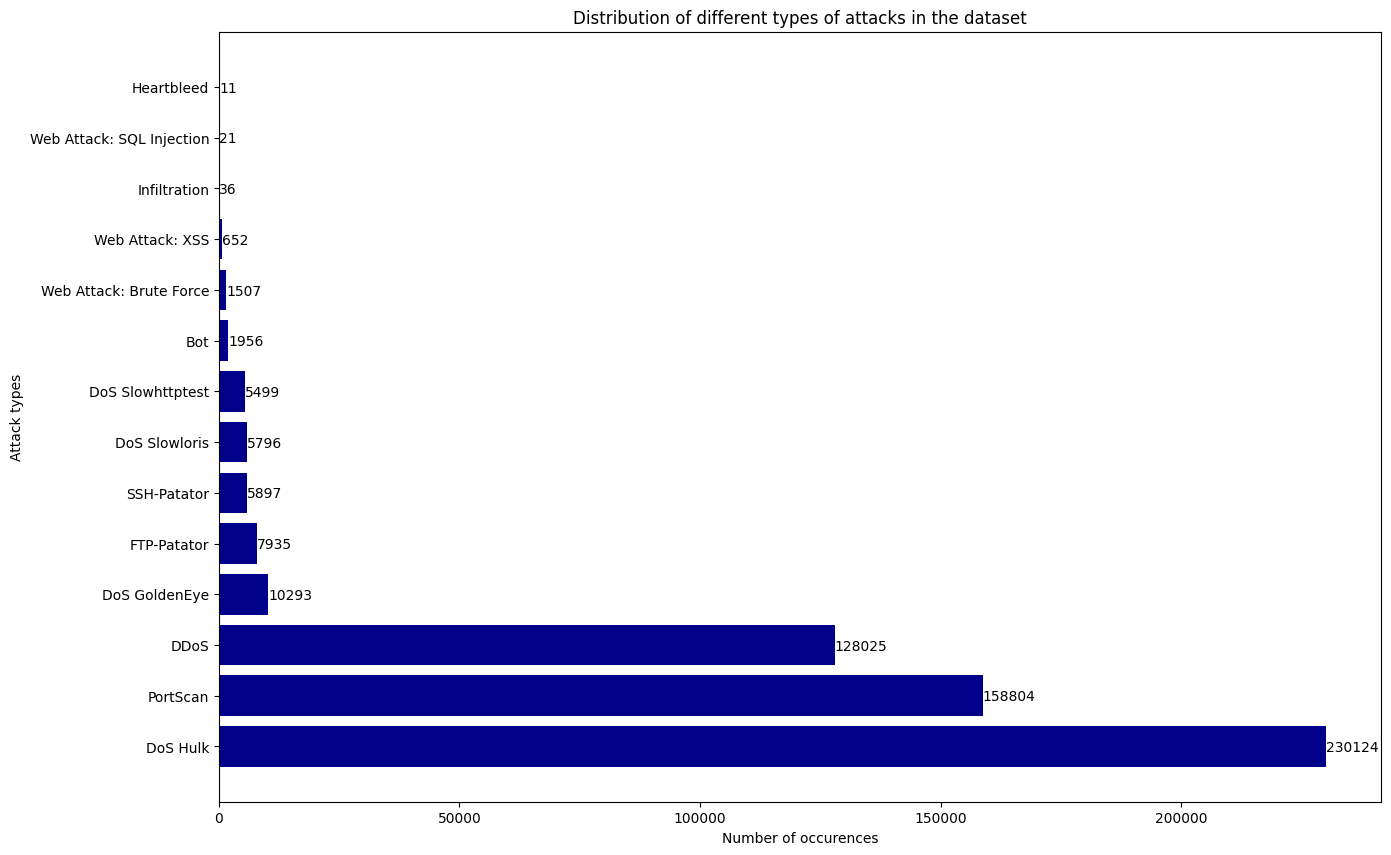

In [15]:
plt.figure(figsize=(15,10))
attack = ('DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye', 'FTP-Patator', 'SSH-Patator', 'DoS Slowloris',
        'DoS Slowhttptest', 'Bot', 'Web Attack: Brute Force', 'Web Attack: XSS', 'Infiltration', 'Web Attack: SQL Injection', 'Heartbleed')
y_pos = np.arange(len(attack))
amount = dataset['Label'].value_counts()[1:]
plt.barh(y_pos, amount, align='center', color='#00008B' )
plt.yticks(y_pos, attack)
plt.title('Distribution of different types of attacks in the dataset')
plt.xlabel('Number of occurences')
plt.ylabel('Attack types')
for i, v in enumerate(amount):
  plt.text(v + 3, i-0.1 , str(v))

plt.show()

In [16]:
# dataset = dataset.replace(['Heartbleed', 'Web Attack � Sql Injection', 'Infiltration'], np.nan)
# dataset = dataset.dropna()
# dataset['Label'].value_counts()

In [17]:
dataset.loc[dataset.Label == 'Web Attack � Brute Force', ['Label']] = 'Brute Force'
dataset.loc[dataset.Label == 'Web Attack � XSS', ['Label']] = 'XSS'
dataset.loc[dataset.Label == 'Web Attack � Sql Injection', ['Label']] = 'Injection'

In [18]:
dataset['Label'].value_counts()

,count
Label,
BENIGN,2271320
DoS Hulk,230124
PortScan,158804
DDoS,128025
DoS GoldenEye,10293
FTP-Patator,7935
SSH-Patator,5897
DoS slowloris,5796
DoS Slowhttptest,5499


In [19]:
# Create attack column, containing binary labels
dataset['Attack'] = np.where(dataset['Label'] == 'BENIGN', 0, 1)

In [20]:
# Proposed Groupings
attack_group = {'BENIGN': 'benign',
              'DoS Hulk': 'dos',
              'PortScan': 'probe',
              'DDoS': 'ddos',
              'DoS GoldenEye': 'dos',
              'FTP-Patator': 'brute_force',
              'SSH-Patator': 'brute_force',
              'DoS slowloris': 'dos',
              'DoS Slowhttptest': 'dos',
              'Bot': 'botnet',
              'Brute Force': 'web_attack',
              'XSS': 'web_attack',
              'Heartbleed': 'dos',
              'Injection':'web_attack',
              'Infiltration':'infiltration'
              }
# Create grouped label column
dataset['Label_Category'] = dataset['Label'].map(lambda x: attack_group[x])
dataset['Label_Category'].value_counts()

,count
Label_Category,
benign,2271320
dos,251723
probe,158804
ddos,128025
brute_force,13832
web_attack,2180
botnet,1956
infiltration,36


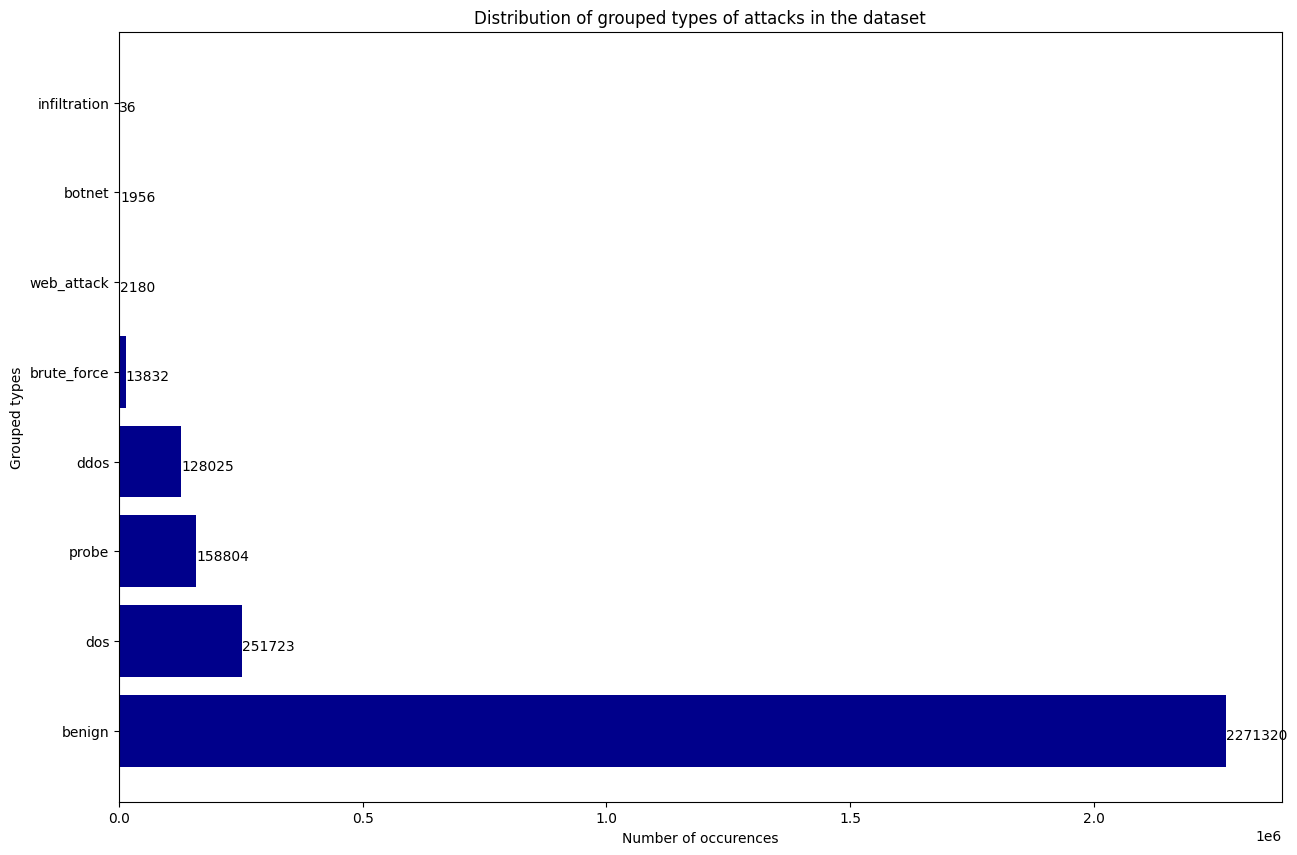

In [21]:
plt.figure(figsize=(15,10))
attack = ('benign', 'dos', 'probe', 'ddos', 'brute_force', 'web_attack', 'botnet','infiltration')
y_pos = np.arange(len(attack))
amount = dataset['Label_Category'].value_counts()#[1:]
plt.barh(y_pos, amount, align='center', color='#00008B' )
plt.yticks(y_pos, attack)
plt.title('Distribution of grouped types of attacks in the dataset')
plt.xlabel('Number of occurences')
plt.ylabel('Grouped types')
for i, v in enumerate(amount):
  plt.text(v + 3, i-0.1 , str(v))

plt.show()

In [22]:
attacks = ['Label', 'Label_Category', 'Attack']
# xs=feature vectors, ys=labels
xs = dataset.drop(attacks, axis=1)
ys = dataset[attacks]
# split dataset - stratified
x_train, x_temp, y_train, y_temp = train_test_split(xs, ys, test_size=0.4, random_state=0, stratify=ys['Label'])
x_test, x_validate, y_test, y_validate = train_test_split(x_temp, y_temp, test_size=0.5, random_state=0, stratify=y_temp['Label'])

In [23]:
column_names = np.array(list(x_train))
to_drop = []
for x in column_names:
  size = x_train.groupby([x]).size()
  # check for columns that only have one value
  if (len(size.unique()) == 1):
      to_drop.append(x)
to_drop

[np.str_('Bwd_PSH_Flags'),
 np.str_('Bwd_URG_Flags'),
 np.str_('Fwd_Avg_Bytes_Bulk'),
 np.str_('Fwd_Avg_Packets_Bulk'),
 np.str_('Fwd_Avg_Bulk_Rate'),
 np.str_('Bwd_Avg_Bytes_Bulk'),
 np.str_('Bwd_Avg_Packets_Bulk'),
 np.str_('Bwd_Avg_Bulk_Rate')]

In [24]:
x_train = x_train.drop(to_drop, axis=1)
x_validate = x_validate.drop(to_drop, axis=1)
x_test = x_test.drop(to_drop, axis=1)
dataset_copy = dataset.drop(to_drop, axis=1)

In [25]:
# Normalise
min_max_scaler = MinMaxScaler().fit(x_train)
# Apply normalisation to dataset
x_train = min_max_scaler.transform(x_train)
x_validate = min_max_scaler.transform(x_validate)
x_test = min_max_scaler.transform(x_test)
# All values between 0 and 1
pd.Series(x_train.flatten()).describe()

,0
count,1.170740e+08
mean,8.581172e-02
std,2.505981e-01
min,0.000000e+00
25%,0.000000e+00
50%,8.416666e-07
75%,5.808321e-03
max,1.000000e+00


In [26]:
features = SelectKBest(score_func=chi2, k=x_train.shape[1])
#fit features to the training dataset
fit = features.fit(x_train, y_train.Label_Category)

In [27]:
print (len(features.scores_))

69


In [28]:
dataset_copy.columns

Index(['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets',
       'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets',
       'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max',
       'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean',
       'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max',
       'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean',
       'Bwd_Packet_Length_Std', 'Flow_Bytes_s', 'Flow_Packets_s',
       'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min',
       'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max',
       'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std',
       'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Fwd_URG_Flags',
       'Fwd_Header_Length', 'Bwd_Header_Length', 'Fwd_Packets_s',
       'Bwd_Packets_s', 'Min_Packet_Length', 'Max_Packet_Length',
       'Packet_Length_Mean', 'Packet_Length_Std', 'Packet_Length_Variance',
       'FIN_Flag_Count', 'SYN_Flag_Count', 'RST_Flag_Count', 'PSH_Flag_Count',

In [29]:
 A=['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets',
       'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets',
       'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max',
       'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean',
       'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max',
       'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean',
       'Bwd_Packet_Length_Std', 'Flow_Bytes_s', 'Flow_Packets_s',
       'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min',
       'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max',
       'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std',
       'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Fwd_URG_Flags',
       'Fwd_Header_Length', 'Bwd_Header_Length', 'Fwd_Packets_s',
       'Bwd_Packets_s', 'Min_Packet_Length', 'Max_Packet_Length',
       'Packet_Length_Mean', 'Packet_Length_Std', 'Packet_Length_Variance',
       'FIN_Flag_Count', 'SYN_Flag_Count', 'RST_Flag_Count', 'PSH_Flag_Count',
       'ACK_Flag_Count', 'URG_Flag_Count', 'CWE_Flag_Count', 'ECE_Flag_Count',
       'Down_Up_Ratio', 'Average_Packet_Size', 'Avg_Fwd_Segment_Size',
       'Avg_Bwd_Segment_Size', 'Subflow_Fwd_Packets', 'Subflow_Fwd_Bytes',
       'Subflow_Bwd_Packets', 'Subflow_Bwd_Bytes', 'Init_Win_bytes_forward',
       'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward',
       'Active_Mean', 'Active_Std', 'Active_Max', 'Active_Min', 'Idle_Mean',
       'Idle_Std', 'Idle_Max', 'Idle_Min', 'Label', 'Attack',
       'Label_Category']

In [30]:
print(len(A))

72


In [31]:
columns_to_drop = ['Label', 'Attack', 'Label_Category']
dataset_copy.drop(columns=columns_to_drop, inplace=True)

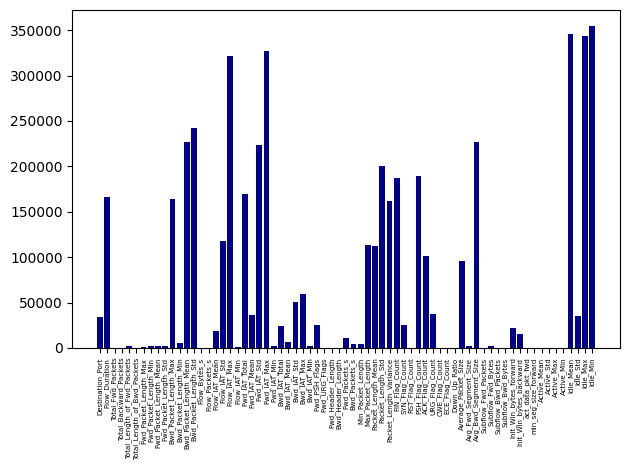

In [32]:
import matplotlib.pyplot as plt
plt.bar([i for i in range(len(features.scores_))], features.scores_, color='#00008B')
plt.xticks([i for i in range(len(features.scores_))], dataset_copy.columns)
plt.xticks(rotation=90, fontsize=5)
plt.tight_layout()
plt.savefig('features.png', dpi=400)

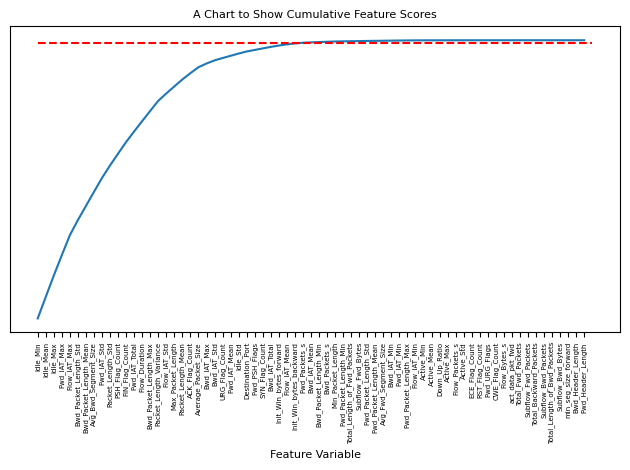

In [33]:
# sort the features by importance score
feature_importances = zip(dataset_copy.columns, features.scores_)
feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)
sorted_importances = [importance[1] for importance in feature_importances]
sorted_features = [importance[0] for importance in feature_importances]
x_values = list(range(len(feature_importances)))
# plot the cumulative scores
cumulative_importances = np.cumsum(sorted_importances)
plt.plot(x_values, cumulative_importances)
# Draw line at 99% of importance retained
value99 = cumulative_importances[-1]*0.99
plt.hlines(y = value99, xmin=0, xmax=len(sorted_importances), color = 'r', linestyles = 'dashed')
plt.xticks(x_values, sorted_features, rotation = 'vertical', fontsize=5)
plt.yticks([], [])
plt.xlabel('Feature Variable', fontsize=8)
plt.title('A Chart to Show Cumulative Feature Scores', fontsize=8)
#plt.figure(figsize=(500,200))
plt.tight_layout()
plt.savefig('cum_features.png', dpi=400)

In [34]:
# perform selectkbest with k=32
features = SelectKBest(score_func=chi2, k=32)
fit = features.fit(x_train, y_train.Label)
x_train = fit.transform(x_train)
x_test = fit.transform(x_test)
x_validate = fit.transform(x_validate)

In [35]:
new_features = dataset_copy.columns[features.get_support(indices=True)]

In [36]:
new_features

Index(['Destination_Port', 'Flow_Duration', 'Bwd_Packet_Length_Max',
       'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_IAT_Std',
       'Flow_IAT_Max', 'Flow_IAT_Min', 'Fwd_IAT_Total', 'Fwd_IAT_Mean',
       'Fwd_IAT_Std', 'Fwd_IAT_Max', 'Bwd_IAT_Total', 'Bwd_IAT_Std',
       'Bwd_IAT_Max', 'Fwd_PSH_Flags', 'Max_Packet_Length',
       'Packet_Length_Mean', 'Packet_Length_Std', 'Packet_Length_Variance',
       'FIN_Flag_Count', 'SYN_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count',
       'URG_Flag_Count', 'Average_Packet_Size', 'Avg_Bwd_Segment_Size',
       'Init_Win_bytes_forward', 'Idle_Mean', 'Idle_Std', 'Idle_Max',
       'Idle_Min'],
      dtype='object')

In [37]:
attack_groups = np.array(['benign', 'botnet', 'brute_force', 'ddos', 'dos', 'probe', 'web_attack','infiltration'])

In [38]:
#precision_svm_2, recall_svm_2, fscore_svm_2, n = score(y_test.Label_Category, y_test_predicted, average='macro')
#accuracy_svm_2 = accuracy_score(y_test.Label_Category, y_test_predicted)

In [39]:
classifier =  RandomForestClassifier()

In [40]:
# fit the model
start = time.time()
classifier.fit(x_train, y_train.Label_Category)
end = time.time()
training_time = end - start
# validation
start = time.time()
y_validate_predicted = classifier.predict(x_validate)
end = time.time()
predict_time = end  - start
print(training_time, predict_time)
# Testing
start = time.time()
y_test_predicted = classifier.predict(x_test)
end = time.time()
testing_time = end  - start
print(training_time, predict_time, testing_time)
confusion_rf_1 = pd.crosstab(y_test.Label_Category, y_test_predicted)
confusion_rf_1

1251.6552565097809 10.536367893218994
1251.6552565097809 10.536367893218994 11.093998193740845


col_0,benign,botnet,brute_force,ddos,dos,infiltration,probe,web_attack
Label_Category,,,,,,,,
benign,453919,55,2,2,91,0,184,11
botnet,80,311,0,0,0,0,0,0
brute_force,4,0,2762,0,0,0,0,0
ddos,13,0,0,25592,0,0,0,0
dos,49,0,0,0,50295,0,0,0
infiltration,1,0,0,0,0,6,0,0
probe,129,0,0,0,10,0,31621,1
web_attack,42,0,0,0,0,0,2,393


In [41]:
precision, recall, fscore, support = score(y_test.Label_Category, y_test_predicted)
d = {'attack': attack_groups, 'precision': precision, 'recall' : recall, 'fscore': fscore}
results = pd.DataFrame(data=d)
results

,attack,precision,recall,fscore
0,benign,0.999300,0.999241,0.999270
1,botnet,0.849727,0.795396,0.821664
2,brute_force,0.999276,0.998554,0.998915
3,ddos,0.999922,0.999492,0.999707
4,dos,0.997996,0.999027,0.998511
5,probe,1.000000,0.857143,0.923077
6,web_attack,0.994152,0.995592,0.994872
7,infiltration,0.970370,0.899314,0.933492


In [42]:
precision_rf_1, recall_rf_1, fscore_rf_1, n = score(y_test.Label_Category, y_test_predicted, average = 'macro')
accuracy_rf_1 = accuracy_score(y_test.Label_Category, y_test_predicted)

In [43]:
# fit the model
start = time.time()
classifier.fit(x_train, y_train.Attack)# Binary
end = time.time()
training_time = end - start
start = time.time()
y_validation_predicted = classifier.predict(x_validate)
end = time.time()
validation_time = end  - start

# test
start = time.time()
y_test_predicted = classifier.predict(x_test)
end = time.time()
testing_time = end  - start
print(training_time, validation_time, testing_time)
confusion_rf_2 = pd.crosstab(y_test.Attack, y_test_predicted)
confusion_rf_2

1176.796189546585 7.832194805145264 9.554311513900757


col_0,0,1
Attack,,
0,453911,353
1,330,110981


In [44]:
precision, recall, fscore, support = score(y_test.Attack, y_test_predicted)
d = {'attack': [0,1], 'precision': precision, 'recall' : recall, 'fscore': fscore}
results = pd.DataFrame(data=d)
results

,attack,precision,recall,fscore
0,0,0.999274,0.999223,0.999248
1,1,0.996829,0.997035,0.996932


In [45]:
precision_rf_2, recall_rf_2, fscore_rf_2, n = score(y_test.Attack, y_test_predicted, average = 'macro')
accuracy_rf_2 = accuracy_score(y_test.Attack, y_test_predicted)

In [46]:
print('Random Forrest: Precision / Recall / FScore / Accuracy')
print('Grouped labels:', precision_rf_1, recall_rf_1, fscore_rf_1, accuracy_rf_1)
print('Binary labels:', precision_rf_2, recall_rf_2, fscore_rf_2, accuracy_rf_2)

Random Forrest: Precision / Recall / FScore / Accuracy
Grouped labels: 0.9763429302835984 0.942969779648685 0.9586884984425221 0.9988047562215444
Binary labels: 0.9980514368512533 0.9981291261332452 0.9980902758525977 0.9987923794368563


## Save Processed Data for Part 2 (Adversarial Attacks)

All the processed data, models, and analysis results are saved here for use in subsequent parts.

In [47]:
# Save all processed data and models for Part 2 (Adversarial Attacks)
import pickle
import joblib

print(" SAVING PROCESSED DATA FOR PART 2")
print("=" * 50)

# Create comprehensive data package for Part 2
part1_outputs = {
    # Processed training/test data
    'x_train': x_train,
    'x_test': x_test,
    'x_validate': x_validate,
    'y_train': y_train,
    'y_test': y_test,
    'y_validate': y_validate,

    # Models and transformers
    'classifier': classifier,
    'min_max_scaler': min_max_scaler,
    'features_selector': features,
    'fit_features': fit,

    # Feature information
    'new_features': new_features,
    'attack_groups': attack_groups,
    'dataset_copy': dataset_copy,
    'to_drop': to_drop,

    # Results and metrics
    'precision_rf_1': precision_rf_1,
    'recall_rf_1': recall_rf_1,
    'fscore_rf_1': fscore_rf_1,
    'accuracy_rf_1': accuracy_rf_1,
    'precision_rf_2': precision_rf_2,
    'recall_rf_2': recall_rf_2,
    'fscore_rf_2': fscore_rf_2,
    'accuracy_rf_2': accuracy_rf_2,

    # For vulnerability analysis
    'confusion_rf_1': confusion_rf_1,
    'confusion_rf_2': confusion_rf_2,
    'training_time': training_time,
    'testing_time': testing_time
}

# Save complete outputs
with open('/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/part1_baseline_outputs.pkl', 'wb') as f:
    pickle.dump(part1_outputs, f)

# Save individual components for easier loading
joblib.dump(classifier, '/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/classifier_rf.pkl')
joblib.dump(min_max_scaler, '/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/min_max_scaler.pkl')
joblib.dump(features, '/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/features_selector.pkl')

# Save data as numpy arrays for faster loading
np.save('/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/x_train.npy', x_train)
np.save('/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/x_test.npy', x_test)
np.save('/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/x_validate.npy', x_validate)

# Save labels as pickle (since they're pandas objects)
y_train.to_pickle('/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/y_train.pkl')
y_test.to_pickle('/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/y_test.pkl')
y_validate.to_pickle('/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/y_validate.pkl')

# Save feature names and attack groups
with open('/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/feature_info.pkl', 'wb') as f:
    pickle.dump({
        'new_features': new_features,
        'attack_groups': attack_groups,
        'to_drop': to_drop
    }, f)

print("Saved: part1_baseline_outputs.pkl")
print("Saved: Individual model and data files")
print("Saved: Feature information")

print("\n FILES CREATED FOR PART 2:")
print("1. part1_baseline_outputs.pkl - Complete outputs")
print("2. classifier_rf.pkl - Random Forest model")
print("3. min_max_scaler.pkl - Data scaler")
print("4. features_selector.pkl - Feature selector")
print("5. x_train.npy, x_test.npy, x_validate.npy - Training data")
print("6. y_train.pkl, y_test.pkl, y_validate.pkl - Labels")
print("7. feature_info.pkl - Feature metadata")

print("\n PART 1 COMPLETED SUCCESSFULLY!")
print(" Next: Run Part 2 (Adversarial Attacks)")
print(f" Random Forest Accuracy: {accuracy_rf_1:.4f} (grouped), {accuracy_rf_2:.4f} (binary)")
print(f" Attack groups: {list(attack_groups)}")
print(f" Selected features: {len(new_features)}")

 SAVING PROCESSED DATA FOR PART 2
Saved: part1_baseline_outputs.pkl
Saved: Individual model and data files
Saved: Feature information

 FILES CREATED FOR PART 2:
1. part1_baseline_outputs.pkl - Complete outputs
2. classifier_rf.pkl - Random Forest model
3. min_max_scaler.pkl - Data scaler
4. features_selector.pkl - Feature selector
5. x_train.npy, x_test.npy, x_validate.npy - Training data
6. y_train.pkl, y_test.pkl, y_validate.pkl - Labels
7. feature_info.pkl - Feature metadata

 PART 1 COMPLETED SUCCESSFULLY!
 Next: Run Part 2 (Adversarial Attacks)
 Random Forest Accuracy: 0.9988 (grouped), 0.9988 (binary)
 Attack groups: [np.str_('benign'), np.str_('botnet'), np.str_('brute_force'), np.str_('ddos'), np.str_('dos'), np.str_('probe'), np.str_('web_attack'), np.str_('infiltration')]
 Selected features: 32


In [48]:
# Optional: Download files for backup
from google.colab import files

print("DOWNLOAD FILES (Optional)")
print("=" * 50)

# Uncomment the lines below to download key files to your local machine
files.download('/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/part1_baseline_outputs.pkl')
files.download('/content/drive/MyDrive/Colab Notebooks/Research/Outputs_Part1/classifier_rf.pkl')

print("Tip: Uncomment download commands above to backup files locally")
print("All files are saved in /content/ directory for Part 2")
print("\n Ready to proceed to Part 2: Adversarial Attacks!")

DOWNLOAD FILES (Optional)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tip: Uncomment download commands above to backup files locally
All files are saved in /content/ directory for Part 2

 Ready to proceed to Part 2: Adversarial Attacks!
